# Рекомендательные системы с ALS

Я спарсила 600к взаимодействия пользователей с исполнителями на last.fm. Использовала для старта несколько пользователей из одной секции комментариев, чтобы получить выборку, у которой будет похожий список артистов


In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.sparse as sp
from als import ALS
from sklearn.manifold import TSNE


SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = Path("interactions2.csv")


## Загрузка данных


In [22]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Всего строк: {len(df_raw)}")

df = df_raw[["user_id", "item_id", "interaction", "timestamp"]].copy()
df["interaction"] = df["interaction"].astype(float)

df.head()


Всего строк: 593265


,user_id,item_id,interaction,timestamp
0,stanloonah,Meth Wax,1.0,1766966230
1,stanloonah,Kimiko Glenn,1.0,1766966020
2,stanloonah,NCT DREAM,1.0,1766945092
3,stanloonah,ENHYPEN,1.0,1766945091
4,stanloonah,TAEYONG,1.0,1766945090


## Предобработка


In [23]:
df.groupby(by=['user_id', 'item_id'])[['interaction']].count()

interaction
user_id    item_id                          
Absthedabs $uicideboy$                     6
           50 Cent                         1
           6ix9ine                         1
           A Tribe Called Quest            2
           A$AP Mob                        2
...                                      ...
zoictica   blink-182                       6
           eleventwelfth                  17
           girl in red                     5
           kmoe                            4
           waveform*                       1

[146030 rows x 1 columns]

Пользователей: 1194, предметов: 38657, взаимодействий: 593265


,count_per_user,count_per_item
count,1194.000000,38656.000000
mean,496.871859,15.347216
std,21.165088,101.528669
min,100.000000,1.000000
50%,500.000000,2.000000
90%,500.000000,19.000000
95%,500.000000,45.000000
max,500.000000,7017.000000


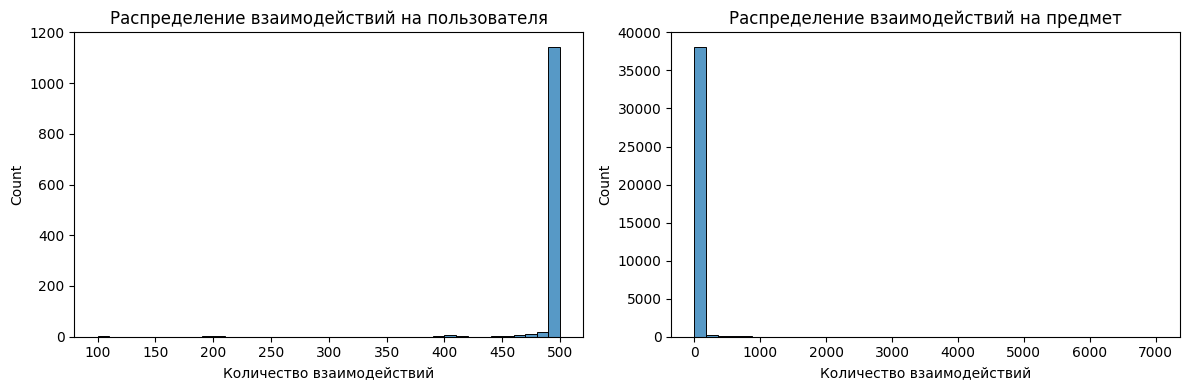

In [24]:
def describe_interactions(frame: pd.DataFrame):
    n_users = len(frame["user_id"].unique())
    n_items = len(frame["item_id"].unique())
    interactions_per_user = frame.groupby("user_id").size()
    interactions_per_item = frame.groupby("item_id").size()

    print(f"Пользователей: {n_users}, предметов: {n_items}, взаимодействий: {len(frame)}")

    stats = pd.DataFrame(
        {
            "count_per_user": interactions_per_user.describe(percentiles=[0.5, 0.9, 0.95]),
            "count_per_item": interactions_per_item.describe(percentiles=[0.5, 0.9, 0.95]),
        }
    )
    display(stats)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(interactions_per_user, bins=40, ax=axes[0])
    axes[0].set_title("Распределение взаимодействий на пользователя")
    axes[0].set_xlabel("Количество взаимодействий")

    sns.histplot(interactions_per_item, bins=40, ax=axes[1])
    axes[1].set_title("Распределение взаимодействий на предмет")
    axes[1].set_xlabel("Количество взаимодействий")

    plt.tight_layout()
    plt.show()

describe_interactions(df)

Удаляю пользователей и предметы с <100 взаимодействий

Размер после фильтрации: 353880 (−239385 строк)
Пользователей: 1127, предметов: 925, взаимодействий: 353880


,count_per_user,count_per_item
count,1127.000000,925.000000
mean,314.001775,382.572973
std,98.794915,530.672993
min,100.000000,100.000000
50%,320.000000,206.000000
90%,442.000000,816.000000
95%,467.000000,1247.000000
max,500.000000,7013.000000


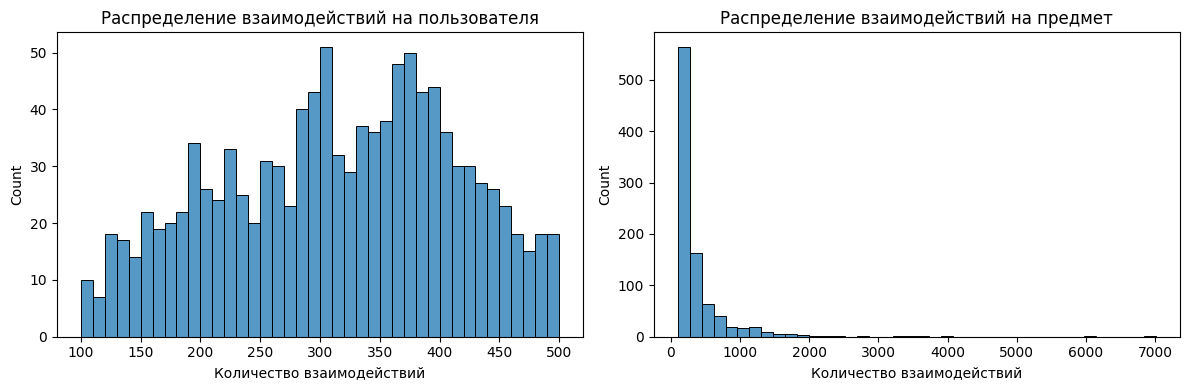

In [25]:
def filter_by_min_interactions(frame: pd.DataFrame, min_interactions: int = 2) -> pd.DataFrame:
    filtered = frame.copy()
    prev_size = -1
    while prev_size != len(filtered):
        prev_size = len(filtered)
        users = filtered["user_id"].value_counts()
        items = filtered["item_id"].value_counts()

        keep_users = users[users >= min_interactions].index
        keep_items = items[items >= min_interactions].index

        filtered = filtered[
            filtered["user_id"].isin(keep_users) & filtered["item_id"].isin(keep_items)
        ]
    return filtered


df_clean = filter_by_min_interactions(df, min_interactions=100)
print(f"Размер после фильтрации: {len(df_clean)} (−{len(df) - len(df_clean)} строк)")
describe_interactions(df_clean)


Разбиение по пользователям и времени

In [26]:
def user_based_split(frame: pd.DataFrame, test_ratio: float = 0.1):
    train_parts, test_parts = [], []
    for user, user_df in frame.groupby("user_id"):
        user_df = user_df.sort_values("timestamp")
        n = len(user_df)
        test_size = max(1, int(np.floor(test_ratio * n)))
        if n - test_size < 1:
            test_size = 1

        train_part = user_df.iloc[:-test_size]
        test_part = user_df.iloc[-test_size:]

        train_parts.append(train_part)
        test_parts.append(test_part)

    train_df = pd.concat(train_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)
    return train_df, test_df


train_df, test_df = user_based_split(df_clean, test_ratio=0.2)
print(f"Train: {train_df.shape}, Test: {test_df.shape}")
print(f"Пользователи в тесте: {test_df['user_id'].nunique()}")

Train: (283542, 4), Test: (70338, 4)
Пользователи в тесте: 1127


In [27]:
train_items_by_user = train_df.groupby("user_id")["item_id"].apply(set).to_dict()
test_items_by_user = test_df.groupby("user_id")["item_id"].apply(set).to_dict()

## Baseline


In [28]:
def precision_recall_at_k(recommendations: dict, ground_truth: dict, k: int = 10):
    precisions, recalls = [], []
    for user, true_items in ground_truth.items():
        recs = recommendations.get(user, [])[:k]
        hits = len(set(recs) & true_items)
        precisions.append(hits / k)
        recalls.append(hits / max(len(true_items), 1))
    return float(np.mean(precisions)), float(np.mean(recalls))


def top_popular_recs(train_df: pd.DataFrame, train_items_by_user: dict, k: int = 10):
    popularity = train_df.groupby("item_id")["interaction"].sum().sort_values(ascending=False)
    top_items = popularity.index.tolist()

    recs = {}
    for user, seen_items in train_items_by_user.items():
        user_recs = [item for item in top_items if item not in seen_items][:k]
        recs[user] = user_recs
    return recs, popularity


top_pop_recs, popularity = top_popular_recs(train_df, train_items_by_user, k=10)
tp_precision, tp_recall = precision_recall_at_k(top_pop_recs, test_items_by_user, k=10)
print(f"Top Popular Precision@10={tp_precision:.4f}, Recall@10={tp_recall:.4f}")


Top Popular Precision@10=0.0320, Recall@10=0.0169


## ALS


In [29]:
user_idx = {u: i for i, u in enumerate(train_df["user_id"].unique())}
item_idx = {i: j for j, i in enumerate(train_df["item_id"].unique())}

idx_to_item = pd.Series({j: i for i, j in item_idx.items()})
idx_to_user = pd.Series({i: u for u, i in user_idx.items()})

rows = train_df["user_id"].map(user_idx)
cols = train_df["item_id"].map(item_idx)
data = train_df["interaction"].astype(float)

user_item_csr = sp.csr_matrix(
    (data, (rows, cols)),
    shape=(len(user_idx), len(item_idx))
)

als_model = ALS(
    factors=64,
    alpha=40.0,
    reg=0.10,
    iterations=100,
    random_state=SEED,
)
als_model.fit(user_item_csr)


ALS(factors=64, alpha=40.0, reg=0.1, iterations=100, random_state=42, user_factors=array([[-0.94030791, -1.38688433, -2.67584586, ...,  2.75080312,
         0.75369974, -0.3227941 ],
       [ 1.43481091, -1.45781296,  0.71935884, ...,  3.19937462,
        -0.56027294, -1.11768647],
       [ 3.00185402, -1.22450896,  1.99824206, ...,  0.75572964,
         2.72941555, -0.40251124],
       ...,
       [ 1.67135876, -2.41896221, -1.04022802, ...,  1.58477386,
         1.99610796, -2.40055399],
       [-2.44549729, -1.45269878, -4.47966266, ...,  3.61521292,
         1.77805806,  2.56466711],
       [-0.12576334, -4.43440331,  0.31621618, ...,  1.49020379,
         0.8263122 , -1.04566777]], shape=(1127, 64)), item_factors=array([[-0.01665168, -0.00703546,  0.05976139, ..., -0.00095354,
        -0.01971424, -0.03888068],
       [-0.01273785, -0.02145932,  0.01486264, ...,  0.02981582,
         0.05226618,  0.00341703],
       [ 0.02001952,  0.04092189, -0.00511774, ...,  0.02263074,
       

In [30]:
def als_recommendations(model, idx_to_user, idx_to_item, user_items: sp.csr_matrix, k: int = 10) -> dict:
    recs = {}
    for u_idx, user in idx_to_user.items():
        ids = model.recommend(
            user_id=int(u_idx),
            user_items=user_items[u_idx],
            N=k,
            filter_items=[]
        )
        recs[user] = idx_to_item.loc[ids].tolist()
    return recs



als_recs = als_recommendations(
    als_model,
    idx_to_user=idx_to_user,
    idx_to_item=idx_to_item,
    user_items=user_item_csr,
    k=10
)


als_precision, als_recall = precision_recall_at_k(als_recs, test_items_by_user, k=10)
print(f"ALS Precision@10={als_precision:.4f}, Recall@10={als_recall:.4f}")


ALS Precision@10=0.2756, Recall@10=0.2626


## Сравнение метрик


In [31]:

print(f"Top Popular Precision@10 = { tp_precision:.4f}, Recall@10 = { tp_recall:.4f}")
print(f"        ALS Precision@10 = {als_precision:.4f}, Recall@10 = {als_recall:.4f}")

Top Popular Precision@10 = 0.0320, Recall@10 = 0.0169
        ALS Precision@10 = 0.2756, Recall@10 = 0.2626


Считаю это победа

## Визуализация эмбеддингов


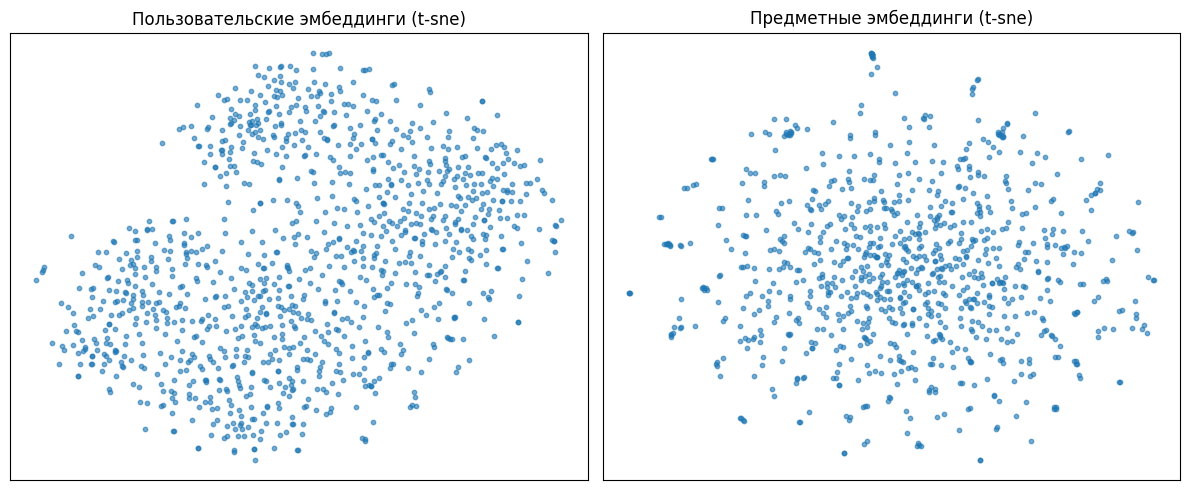

In [32]:
def reduce_embeddings(embeddings: np.ndarray):
    reducer = TSNE(n_components=2, random_state=SEED, init="random", perplexity=30)
    coords = reducer.fit_transform(embeddings)
    return coords


user_coords = reduce_embeddings(als_model.user_factors)
item_coords = reduce_embeddings(als_model.item_factors)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(user_coords[:, 0], user_coords[:, 1], s=10, alpha=0.6)
axes[0].set_title("Пользовательские эмбеддинги (t-sne)")
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].scatter(item_coords[:, 0], item_coords[:, 1], s=10, alpha=0.6)
axes[1].set_title("Предметные эмбеддинги (t-sne)")
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()
